# 3. Data Exploration

The purpose of this notebook is to explore the data and test out different features impact on is_churn. We try to narrow down our number of features to only a handful of powerful features.

## 1. Load Data and Merge

Here we load our two previously generated data files, "mult_cohort_transaction_data.csv" and "mult_cohort_usage_data.parquet."We also load in the "member_v3.csv" to explore if any member features contribute to is_churn. We merge these three data frames along msno and cohort_cutoff_date.

In [ ]:
# --------------------------------------------------------------------
# Imports and settings
# --------------------------------------------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import log_loss
from sklearn.metrics import roc_auc_score
import warnings
import os
from datetime import datetime

warnings.filterwarnings('ignore')
%matplotlib inline
sns.set_style('whitegrid')
pd.set_option('display.max_columns', 100)

In [ ]:
DATA_DIR = "../data/"

In [ ]:
# --------------------------------------------------------------------
# Load the three  CSV files
# --------------------------------------------------------------------
# We parse dates automatically

trans_data = pd.read_csv(os.path.join(DATA_DIR, "processed/", "mult_cohort_transaction_data.csv"), parse_dates = ["last_transaction_date", "cohort_cutoff_date"])

usage_data = pd.read_parquet(os.path.join(DATA_DIR, "processed/", "mult_cohort_usage_data.parquet"))
usage_data["cohort_cutoff_date"] = pd.to_datetime(usage_data["cohort_cutoff_date"])

members = pd.read_csv(
    os.path.join(DATA_DIR, "raw/", "members_v3.csv")
)

print("Train shape:", trans_data.shape)
print("Members shape:", members.shape)
print("Usage shape:", usage_data.shape)

Train shape: (16857930, 19)
Members shape: (6769473, 6)
Usage shape: (16857930, 9)


In [ ]:
trans_data.info(show_counts=True)

<class 'pandas.DataFrame'>
RangeIndex: 16857930 entries, 0 to 16857929
Data columns (total 19 columns):
 #   Column                   Non-Null Count     Dtype         
---  ------                   --------------     -----         
 0   msno                     16857930 non-null  str           
 1   is_churn                 16857930 non-null  int64         
 2   num_transactions         16857930 non-null  int64         
 3   total_paid               16857930 non-null  int64         
 4   avg_plan_price           16857930 non-null  float64       
 5   total_auto_renew         16857930 non-null  int64         
 6   total_cancel             16857930 non-null  int64         
 7   last_payment_plan_days   16857930 non-null  int64         
 8   last_plan_list_price     16857930 non-null  int64         
 9   last_actual_amount_paid  16857930 non-null  int64         
 10  last_is_auto_renew       16857930 non-null  int64         
 11  last_transaction_date    16857930 non-null  datetime64[us]


In [ ]:
trans_data.head(10)

,msno,is_churn,num_transactions,total_paid,avg_plan_price,total_auto_renew,total_cancel,last_payment_plan_days,last_plan_list_price,last_actual_amount_paid,last_is_auto_renew,last_transaction_date,last_expire,last_is_cancel,days_since_first_trans,days_since_last_trans,days_to_expire,avg_payment_per_day,cohort_cutoff_date
0,+++snpr7pmobhLKUgSHTv/mpkqgBT0tQJ0zQj6qKrqc=,0,1,149,149.0,1,0,30,149,149,1,2015-01-26,2015-02-26,0,6,6,25,4.806452,2015-02-01
1,++/Gw1B9K+XOlB3hLTloeUK2QlCa2m+BJ8TrzGf7djI=,0,1,149,149.0,1,0,31,149,149,1,2015-01-13,2015-02-16,0,19,19,15,4.382353,2015-02-01
2,++/TR7WI15q2ZCtOXmoap7jR+kEhbMVE5swOqsfqpqI=,0,1,149,149.0,1,0,31,149,149,1,2015-01-24,2015-02-25,0,8,8,24,4.656250,2015-02-01
3,++2axpngZEynlxNr1+AkwgHHfaEZ/EeOj6Q284RiAkw=,0,1,149,149.0,1,0,30,149,149,1,2015-01-31,2015-02-28,0,1,1,27,5.321429,2015-02-01
4,++3FNwZTm6haRgXV0ZRonrNvMxKD9F64lQhIQmQ9wIE=,0,1,149,149.0,1,0,30,149,149,1,2015-01-21,2015-02-21,0,11,11,20,4.806452,2015-02-01
5,++3UnufK0Ka+brv8dKFZUpOV41Jk2uRLYSWIkT6Ff6c=,0,1,149,149.0,1,0,30,149,149,1,2015-01-08,2015-02-08,0,24,24,7,4.806452,2015-02-01
6,++3Z+W8OPnpbHYfrKwqRKN1bF83XEbxjdYUolhGdHZg=,0,1,149,149.0,1,0,30,149,149,1,2015-01-08,2015-02-09,0,24,24,8,4.656250,2015-02-01
7,++4RuqBw0Ss6bQU4oMxaRlbBPoWzoEiIZaxPM04Y4+U=,0,1,129,129.0,1,0,30,129,129,1,2015-01-13,2015-02-13,0,19,19,12,4.161290,2015-02-01
8,++4cUL0b9CfW8cj0A/wfSxQc4k4fcVtWcLqk2UOdpKs=,0,1,149,149.0,1,0,30,149,149,1,2015-01-08,2015-02-09,0,24,24,8,4.656250,2015-02-01
9,++5XBxbJNz3idK9egVoGbWJ4xhGQu2MR0pSP0kL9DK4=,0,1,129,129.0,1,0,30,129,129,1,2015-01-18,2015-02-19,0,14,14,18,4.031250,2015-02-01


In [ ]:
usage_data.info(show_counts = True)

<class 'pandas.DataFrame'>
Index: 16857930 entries, 0 to 871425
Data columns (total 9 columns):
 #   Column               Non-Null Count     Dtype        
---  ------               --------------     -----        
 0   msno                 16857930 non-null  str          
 1   cohort_cutoff_date   16857930 non-null  datetime64[s]
 2   days_since_last_use  14343746 non-null  float64      
 3   num_25_velocity      12918564 non-null  float64      
 4   num_75_velocity      12099783 non-null  float64      
 5   num_985_velocity     12073660 non-null  float64      
 6   num_100_velocity     13036373 non-null  float64      
 7   num_unq_velocity     13210846 non-null  float64      
 8   total_secs_velocity  13186832 non-null  float64      
dtypes: datetime64[s](1), float64(7), str(1)
memory usage: 1.9 GB


In [ ]:
usage_data.head(10)

,msno,cohort_cutoff_date,days_since_last_use,num_25_velocity,num_75_velocity,num_985_velocity,num_100_velocity,num_unq_velocity,total_secs_velocity
0,eKdCX4H8Vhv1bUZK8/C3BFndVlc7Cl5xYzTvXEtugTM=,2015-02-01,0.0,0.357724,0.304348,0.298507,0.461358,0.436690,0.443211
1,BNI5Ups+FwpKHMIN/QwiG0/E5PKkBt2y3HIiWE4UrQM=,2015-02-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,M0Sk5UJb1brPp1Jt+L3M3jhXXsEWDxNmINzQUkp1kVs=,2015-02-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,fJOYD1z6/jYrxFKvvxNxJFYNh33399U2HnR3sO4F9jo=,2015-02-01,11.0,0.444444,0.454545,0.571429,0.302326,0.364341,0.354794
4,pf7+HsqacgHhfbOLvCtbhzw7Bohxo6rsSQ7U2PdtH1c=,2015-02-01,3.0,0.562500,NaN,0.200000,0.238095,0.322222,0.244448
5,mp9ZTOgIrHVF0Es4f+bptmOsPs1L++w7mGTl2tg+YPw=,2015-02-01,0.0,0.892857,0.333333,0.000000,0.630566,0.711864,0.627481
6,uKUlx0ffjta9LwKO1O4niFdlYCv92P4I1HytODIooXQ=,2015-02-01,2.0,0.500000,NaN,1.000000,0.404624,0.406780,0.404752
7,IFpnMkho5pYRoLmpYPQwebnydW/zO5KLBetzZErJPiI=,2015-02-01,0.0,0.375000,0.500000,0.142857,0.228710,0.254274,0.246085
8,jM3pF7lrKZEmyUT+5YkLiDrbyBpy5NzF0J8DF8pi10E=,2015-02-01,3.0,0.230088,0.428571,0.200000,0.195122,0.160920,0.202804
9,AC4AKT+PeWY2lMuE09TVGBOyXFIxdz6FehPq4oijtDY=,2015-02-01,29.0,NaN,NaN,NaN,NaN,0.000000,0.000000


In [ ]:
#We merge these three together into one massive data frame
members = pd.merge(trans_data, members, on = 'msno', how = 'left')
members = pd.merge(members, usage_data, on = ['msno', 'cohort_cutoff_date'], how = 'left')

In [ ]:
members.head(10)

,msno,is_churn,num_transactions,total_paid,avg_plan_price,total_auto_renew,total_cancel,last_payment_plan_days,last_plan_list_price,last_actual_amount_paid,last_is_auto_renew,last_transaction_date,last_expire,last_is_cancel,days_since_first_trans,days_since_last_trans,days_to_expire,avg_payment_per_day,cohort_cutoff_date,city,bd,gender,registered_via,registration_init_time,days_since_last_use,num_25_velocity,num_75_velocity,num_985_velocity,num_100_velocity,num_unq_velocity,total_secs_velocity
0,+++snpr7pmobhLKUgSHTv/mpkqgBT0tQJ0zQj6qKrqc=,0,1,149,149.0,1,0,30,149,149,1,2015-01-26,2015-02-26,0,6,6,25,4.806452,2015-02-01,1.0,0.0,NaN,7.0,20140927.0,0.0,0.628527,0.592920,0.568966,0.493279,0.507880,0.494680
1,++/Gw1B9K+XOlB3hLTloeUK2QlCa2m+BJ8TrzGf7djI=,0,1,149,149.0,1,0,31,149,149,1,2015-01-13,2015-02-16,0,19,19,15,4.382353,2015-02-01,15.0,32.0,male,3.0,20121217.0,0.0,0.670455,0.666667,0.500000,0.469307,0.490090,0.469975
2,++/TR7WI15q2ZCtOXmoap7jR+kEhbMVE5swOqsfqpqI=,0,1,149,149.0,1,0,31,149,149,1,2015-01-24,2015-02-25,0,8,8,24,4.656250,2015-02-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,++2axpngZEynlxNr1+AkwgHHfaEZ/EeOj6Q284RiAkw=,0,1,149,149.0,1,0,30,149,149,1,2015-01-31,2015-02-28,0,1,1,27,5.321429,2015-02-01,1.0,0.0,NaN,7.0,20131029.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,++3FNwZTm6haRgXV0ZRonrNvMxKD9F64lQhIQmQ9wIE=,0,1,149,149.0,1,0,30,149,149,1,2015-01-21,2015-02-21,0,11,11,20,4.806452,2015-02-01,1.0,0.0,NaN,7.0,20140822.0,15.0,0.000000,NaN,NaN,0.000000,0.000000,0.000000
5,++3UnufK0Ka+brv8dKFZUpOV41Jk2uRLYSWIkT6Ff6c=,0,1,149,149.0,1,0,30,149,149,1,2015-01-08,2015-02-08,0,24,24,7,4.806452,2015-02-01,10.0,27.0,male,7.0,20131109.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,++3Z+W8OPnpbHYfrKwqRKN1bF83XEbxjdYUolhGdHZg=,0,1,149,149.0,1,0,30,149,149,1,2015-01-08,2015-02-09,0,24,24,8,4.656250,2015-02-01,5.0,35.0,female,7.0,20120209.0,0.0,0.384615,0.600000,0.500000,0.414634,0.326923,0.353206
7,++4RuqBw0Ss6bQU4oMxaRlbBPoWzoEiIZaxPM04Y4+U=,0,1,129,129.0,1,0,30,129,129,1,2015-01-13,2015-02-13,0,19,19,12,4.161290,2015-02-01,1.0,0.0,NaN,7.0,20140714.0,2.0,0.360656,0.333333,0.000000,0.295181,0.302752,0.292404
8,++4cUL0b9CfW8cj0A/wfSxQc4k4fcVtWcLqk2UOdpKs=,0,1,149,149.0,1,0,30,149,149,1,2015-01-08,2015-02-09,0,24,24,8,4.656250,2015-02-01,15.0,28.0,male,7.0,20121009.0,1.0,0.588235,0.400000,0.214286,0.416964,0.521490,0.413965
9,++5XBxbJNz3idK9egVoGbWJ4xhGQu2MR0pSP0kL9DK4=,0,1,129,129.0,1,0,30,129,129,1,2015-01-18,2015-02-19,0,14,14,18,4.031250,2015-02-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
members.info(show_counts = True)

<class 'pandas.DataFrame'>
RangeIndex: 16857930 entries, 0 to 16857929
Data columns (total 31 columns):
 #   Column                   Non-Null Count     Dtype         
---  ------                   --------------     -----         
 0   msno                     16857930 non-null  str           
 1   is_churn                 16857930 non-null  int64         
 2   num_transactions         16857930 non-null  int64         
 3   total_paid               16857930 non-null  int64         
 4   avg_plan_price           16857930 non-null  float64       
 5   total_auto_renew         16857930 non-null  int64         
 6   total_cancel             16857930 non-null  int64         
 7   last_payment_plan_days   16857930 non-null  int64         
 8   last_plan_list_price     16857930 non-null  int64         
 9   last_actual_amount_paid  16857930 non-null  int64         
 10  last_is_auto_renew       16857930 non-null  int64         
 11  last_transaction_date    16857930 non-null  datetime64[us]


In [ ]:
#To free up space, we delete the other dataframes
del trans_data
del usage_data

### We can see that we have lots of missingness from the members features as well as some missingness from the usage data.

## 2. Dropping Features

1. The feature bd is supposed to reflect the user's age. We believe this is listed as their age as of the last transaction date given so either in Feb or March 2017. However, since we have generated monthly cohorts from Feb 2015 to Feb 2017, the age feature is unreliable as we are not given their exact birth date
2. The feature registration_init_time seems to reflect when the user registered their profile information instead of encoding when they joined the service. Since there are some users that have registration_init_time beyond the last date that we are looking at, this feature seems unreliable to use.

We drop both of these features

In [ ]:
members.drop(['bd'], inplace = True, axis = 1)

In [ ]:
members.head()

,msno,is_churn,num_transactions,total_paid,avg_plan_price,total_auto_renew,total_cancel,last_payment_plan_days,last_plan_list_price,last_actual_amount_paid,last_is_auto_renew,last_transaction_date,last_expire,last_is_cancel,days_since_first_trans,days_since_last_trans,days_to_expire,avg_payment_per_day,cohort_cutoff_date,city,gender,registered_via,registration_init_time,days_since_last_use,num_25_velocity,num_75_velocity,num_985_velocity,num_100_velocity,num_unq_velocity,total_secs_velocity
0,+++snpr7pmobhLKUgSHTv/mpkqgBT0tQJ0zQj6qKrqc=,0,1,149,149.0,1,0,30,149,149,1,2015-01-26,2015-02-26,0,6,6,25,4.806452,2015-02-01,1.0,NaN,7.0,20140927.0,0.0,0.628527,0.592920,0.568966,0.493279,0.50788,0.494680
1,++/Gw1B9K+XOlB3hLTloeUK2QlCa2m+BJ8TrzGf7djI=,0,1,149,149.0,1,0,31,149,149,1,2015-01-13,2015-02-16,0,19,19,15,4.382353,2015-02-01,15.0,male,3.0,20121217.0,0.0,0.670455,0.666667,0.500000,0.469307,0.49009,0.469975
2,++/TR7WI15q2ZCtOXmoap7jR+kEhbMVE5swOqsfqpqI=,0,1,149,149.0,1,0,31,149,149,1,2015-01-24,2015-02-25,0,8,8,24,4.656250,2015-02-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,++2axpngZEynlxNr1+AkwgHHfaEZ/EeOj6Q284RiAkw=,0,1,149,149.0,1,0,30,149,149,1,2015-01-31,2015-02-28,0,1,1,27,5.321429,2015-02-01,1.0,NaN,7.0,20131029.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,++3FNwZTm6haRgXV0ZRonrNvMxKD9F64lQhIQmQ9wIE=,0,1,149,149.0,1,0,30,149,149,1,2015-01-21,2015-02-21,0,11,11,20,4.806452,2015-02-01,1.0,NaN,7.0,20140822.0,15.0,0.000000,NaN,NaN,0.000000,0.00000,0.000000


In [ ]:
members.drop(['registration_init_time'], inplace = True, axis = 1)

In [ ]:
members.head()

,msno,is_churn,num_transactions,total_paid,avg_plan_price,total_auto_renew,total_cancel,last_payment_plan_days,last_plan_list_price,last_actual_amount_paid,last_is_auto_renew,last_transaction_date,last_expire,last_is_cancel,days_since_first_trans,days_since_last_trans,days_to_expire,avg_payment_per_day,cohort_cutoff_date,city,gender,registered_via,days_since_last_use,num_25_velocity,num_75_velocity,num_985_velocity,num_100_velocity,num_unq_velocity,total_secs_velocity
0,+++snpr7pmobhLKUgSHTv/mpkqgBT0tQJ0zQj6qKrqc=,0,1,149,149.0,1,0,30,149,149,1,2015-01-26,2015-02-26,0,6,6,25,4.806452,2015-02-01,1.0,NaN,7.0,0.0,0.628527,0.592920,0.568966,0.493279,0.50788,0.494680
1,++/Gw1B9K+XOlB3hLTloeUK2QlCa2m+BJ8TrzGf7djI=,0,1,149,149.0,1,0,31,149,149,1,2015-01-13,2015-02-16,0,19,19,15,4.382353,2015-02-01,15.0,male,3.0,0.0,0.670455,0.666667,0.500000,0.469307,0.49009,0.469975
2,++/TR7WI15q2ZCtOXmoap7jR+kEhbMVE5swOqsfqpqI=,0,1,149,149.0,1,0,31,149,149,1,2015-01-24,2015-02-25,0,8,8,24,4.656250,2015-02-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,++2axpngZEynlxNr1+AkwgHHfaEZ/EeOj6Q284RiAkw=,0,1,149,149.0,1,0,30,149,149,1,2015-01-31,2015-02-28,0,1,1,27,5.321429,2015-02-01,1.0,NaN,7.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,++3FNwZTm6haRgXV0ZRonrNvMxKD9F64lQhIQmQ9wIE=,0,1,149,149.0,1,0,30,149,149,1,2015-01-21,2015-02-21,0,11,11,20,4.806452,2015-02-01,1.0,NaN,7.0,15.0,0.000000,NaN,NaN,0.000000,0.00000,0.000000


## 3. Train / Test Split

We hold out the last 3 cohorts for final testing. These cohorts are Dec 2016, Jan 2017, Feb 2017

In [ ]:
#We have multiple cohorts of data. we have cohorts for expiration dates in Feb 2015 - Feb 2017. Hence we have 25 cohorts. We will hold out the last three cohorts for final testing.
members_train = members.loc[members['cohort_cutoff_date'] < datetime(2016, 12, 1)]
members_test = members.loc[members['cohort_cutoff_date'] >= datetime(2016, 12, 1)]


In [ ]:
#Sanity check
print(members_train.cohort_cutoff_date.max())
print(members_test.cohort_cutoff_date.min())

2016-11-01 00:00:00
2016-12-01 00:00:00


In [ ]:
members_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 14251672 entries, 0 to 14251671
Data columns (total 29 columns):
 #   Column                   Dtype         
---  ------                   -----         
 0   msno                     str           
 1   is_churn                 int64         
 2   num_transactions         int64         
 3   total_paid               int64         
 4   avg_plan_price           float64       
 5   total_auto_renew         int64         
 6   total_cancel             int64         
 7   last_payment_plan_days   int64         
 8   last_plan_list_price     int64         
 9   last_actual_amount_paid  int64         
 10  last_is_auto_renew       int64         
 11  last_transaction_date    datetime64[us]
 12  last_expire              str           
 13  last_is_cancel           int64         
 14  days_since_first_trans   int64         
 15  days_since_last_trans    int64         
 16  days_to_expire           int64         
 17  avg_payment_per_day      float64    

In [ ]:
members_test.info()

<class 'pandas.DataFrame'>
RangeIndex: 2606258 entries, 14251672 to 16857929
Data columns (total 29 columns):
 #   Column                   Dtype         
---  ------                   -----         
 0   msno                     str           
 1   is_churn                 int64         
 2   num_transactions         int64         
 3   total_paid               int64         
 4   avg_plan_price           float64       
 5   total_auto_renew         int64         
 6   total_cancel             int64         
 7   last_payment_plan_days   int64         
 8   last_plan_list_price     int64         
 9   last_actual_amount_paid  int64         
 10  last_is_auto_renew       int64         
 11  last_transaction_date    datetime64[us]
 12  last_expire              str           
 13  last_is_cancel           int64         
 14  days_since_first_trans   int64         
 15  days_since_last_trans    int64         
 16  days_to_expire           int64         
 17  avg_payment_per_day      float

## 4. Feature Exploration
We plot many boxplots and look at correlations between features to find features that seem to contribute to separating is_churn=0 and is_churn=1

<Axes: xlabel='is_churn', ylabel='num_transactions'>

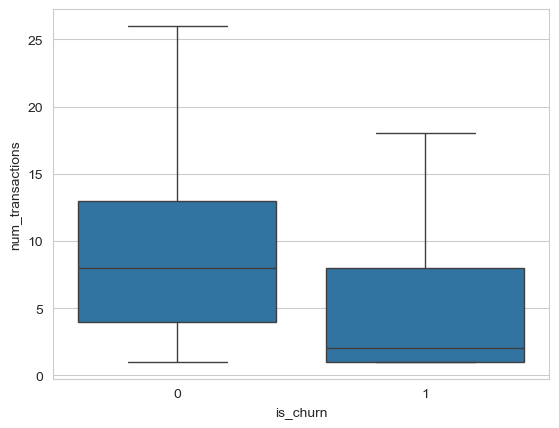

In [ ]:
sns.boxplot(members_train, x = 'is_churn', y = 'num_transactions', showfliers = False)

<Axes: xlabel='is_churn', ylabel='total_paid'>

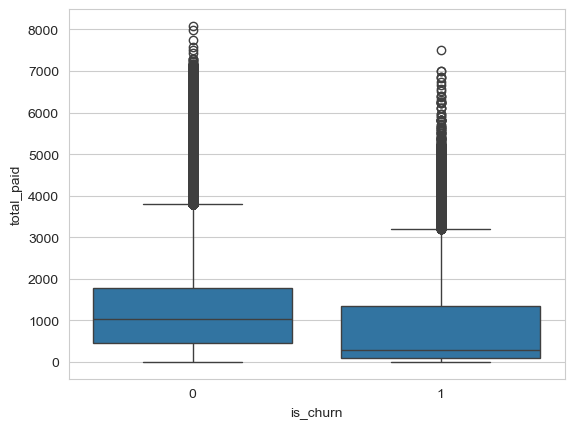

In [ ]:
sns.boxplot(members_train, x = 'is_churn', y = 'total_paid')

<Axes: xlabel='is_churn', ylabel='avg_plan_price'>

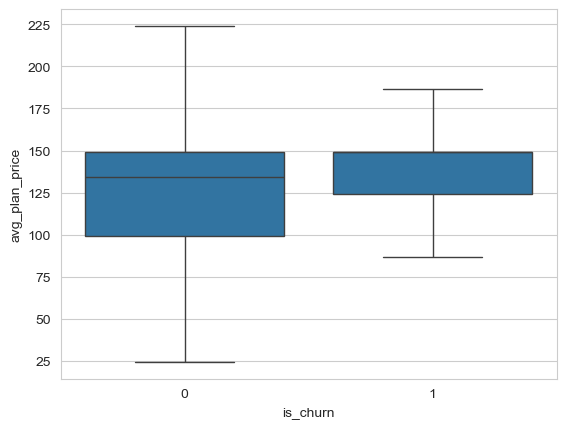

In [ ]:
sns.boxplot(members_train, x = 'is_churn', y = 'avg_plan_price', showfliers = False)

<Axes: xlabel='is_churn', ylabel='last_plan_list_price'>

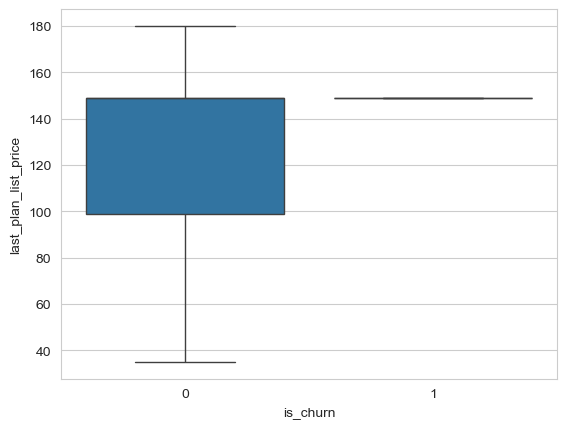

In [ ]:
sns.boxplot(members_train, x = 'is_churn', y = 'last_plan_list_price', showfliers = False)

<Axes: xlabel='is_churn', ylabel='last_actual_amount_paid'>

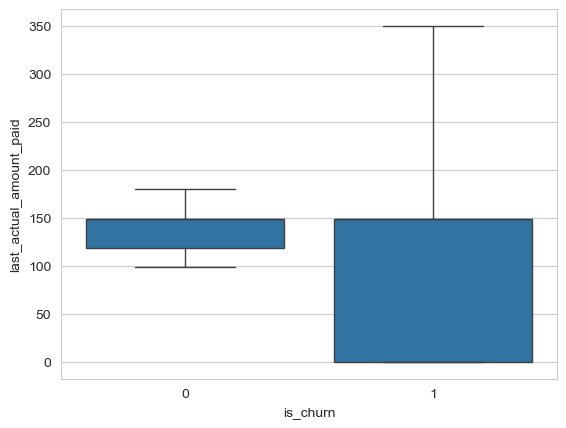

In [ ]:
sns.boxplot(members_train, x = 'is_churn', y = 'last_actual_amount_paid', showfliers = False)

<Axes: xlabel='is_churn', ylabel='total_auto_renew'>

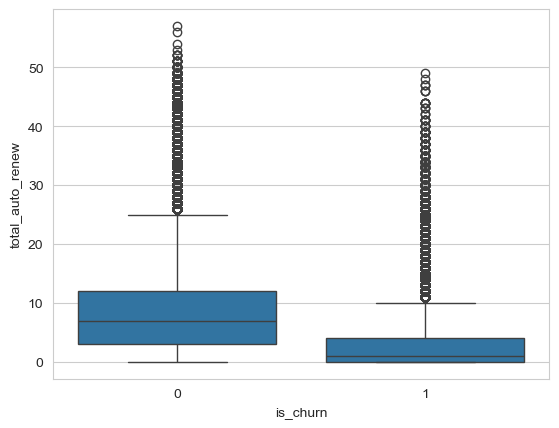

In [ ]:
sns.boxplot(members_train, x = 'is_churn', y = 'total_auto_renew')

In [ ]:
print("is_churn and last_is_auto_renew:", members_train.loc[(members_train['last_is_auto_renew'] == 1) & (members_train['is_churn'] == 1)].shape[0])
print("is_churn and not last_is_auto_renew:", members_train.loc[(members_train['last_is_auto_renew'] == 0) & (members_train['is_churn'] == 1)].shape[0])

print("not is_churn and last_is_auto_renew:", members_train.loc[(members_train['last_is_auto_renew'] == 1) & (members_train['is_churn'] == 0)].shape[0])
print("not is_churn and not last_is_auto_renew:", members_train.loc[(members_train['last_is_auto_renew'] == 0) & (members_train['is_churn'] == 0)].shape[0])

is_churn and last_is_auto_renew: 594646
is_churn and not last_is_auto_renew: 515740
not is_churn and last_is_auto_renew: 11573553
not is_churn and not last_is_auto_renew: 1567733


In [ ]:
#Testing out a new feature... Ratio of auto_renew
members_train['ratio_auto_renew'] = members_train['total_auto_renew'] / members_train['num_transactions']


<Axes: xlabel='is_churn', ylabel='ratio_auto_renew'>

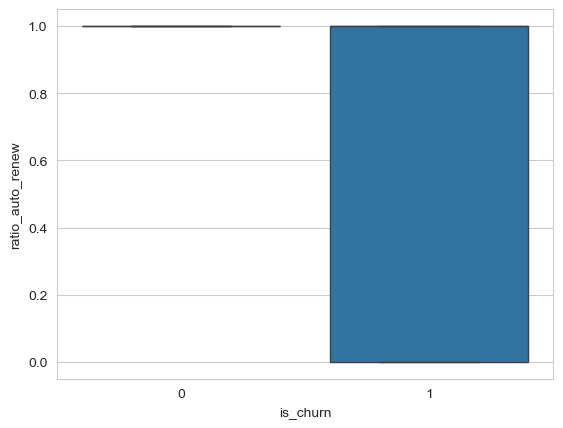

In [ ]:
sns.boxplot(members_train, x = 'is_churn', y = 'ratio_auto_renew', showfliers = False)

### So far the strongest features are last_is_auto_renew and ratio_auto_renew. Also num_transactions, total_paid, and avg_plan_price are also showing promise. Out of these last three, avg_plan_price seems the most detached from length of time that they have been a member. We will also have a feature for days since first transaction that will help encode long term users.



<Axes: xlabel='is_churn', ylabel='total_cancel'>

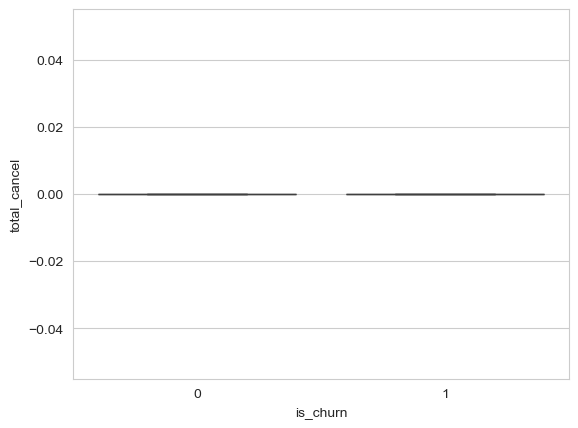

In [ ]:
sns.boxplot(members_train, x = 'is_churn', y = 'total_cancel', showfliers = False)

In [ ]:
print("is_churn and last_is_cancel:", members_train.loc[(members_train['last_is_cancel'] == 1) & (members_train['is_churn'] == 1)].shape[0])
print("is_churn and not last_is_cancel:", members_train.loc[(members_train['last_is_cancel'] == 0) & (members_train['is_churn'] == 1)].shape[0])

print("not is_churn and last_is_cancel:", members_train.loc[(members_train['last_is_cancel'] == 1) & (members_train['is_churn'] == 0)].shape[0])
print("not is_churn and not last_is_cancel:", members_train.loc[(members_train['last_is_cancel'] == 0) & (members_train['is_churn'] == 0)].shape[0])

is_churn and last_is_cancel: 68234
is_churn and not last_is_cancel: 1042152
not is_churn and last_is_cancel: 26583
not is_churn and not last_is_cancel: 13114703


In [ ]:
#Testing out cancel ratio:
members_train['ratio_cancel'] = members_train['total_cancel'] / members_train['num_transactions']

<Axes: xlabel='is_churn', ylabel='ratio_cancel'>

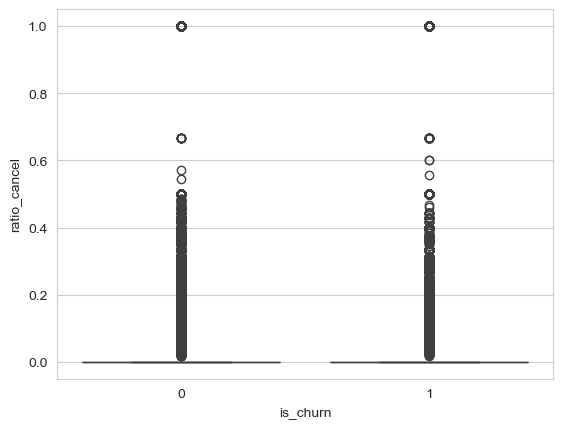

In [ ]:
sns.boxplot(members_train, x = 'is_churn', y = 'ratio_cancel')

<Axes: xlabel='is_churn', ylabel='days_since_first_trans'>

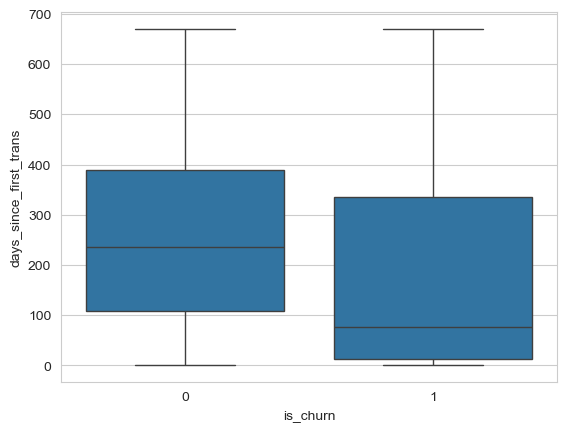

In [ ]:
sns.boxplot(members_train, x = 'is_churn', y = 'days_since_first_trans')

<Axes: xlabel='is_churn', ylabel='days_since_last_trans'>

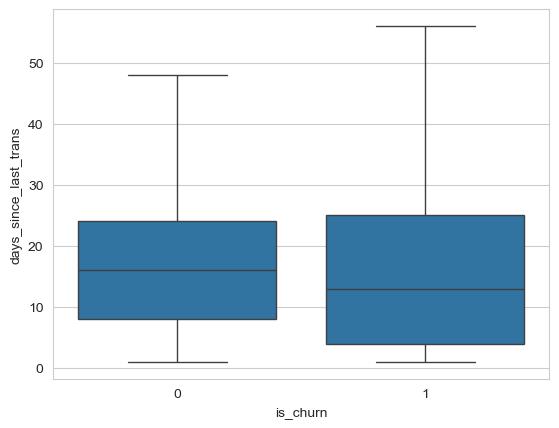

In [ ]:
sns.boxplot(members_train, x = 'is_churn', y = 'days_since_last_trans', showfliers = False)

### The feature last_is_cancel seems promising. Also days_since_first_trans seems promising. Even though days_since_last_trans shows promise in separating, it does not make sense to penalize users that sign up for longer term subscriptions.

<Axes: xlabel='is_churn', ylabel='avg_payment_per_day'>

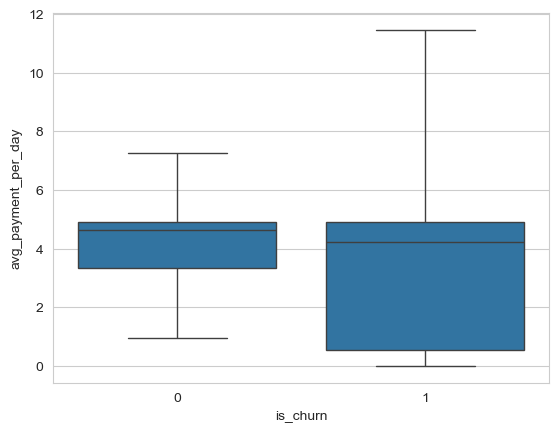

In [ ]:
sns.boxplot(members_train, x = 'is_churn', y = 'avg_payment_per_day', showfliers = False)

<Axes: xlabel='is_churn', ylabel='days_to_expire'>

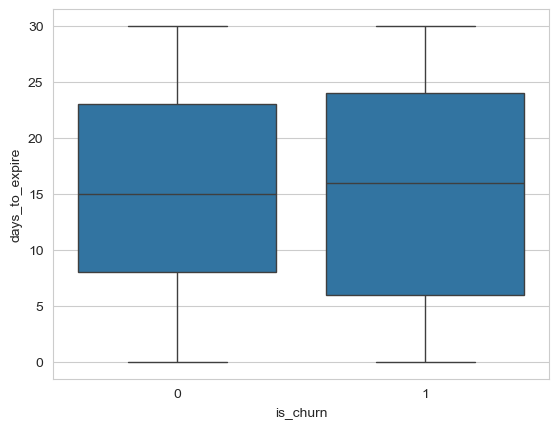

In [ ]:
sns.boxplot(members_train, x = 'is_churn', y = 'days_to_expire', showfliers = False)

In [ ]:
print("male and churn", members_train.loc[(members_train['gender'] == 'male') & (members_train['is_churn'] == True)].shape[0])
print("male and not churn", members_train.loc[(members_train['gender'] == 'male') & (members_train['is_churn'] == False)].shape[0])

print("female and churn", members_train.loc[(members_train['gender'] == 'female') & (members_train['is_churn'] == True)].shape[0])
print("female and not churn", members_train.loc[(members_train['gender'] == 'female') & (members_train['is_churn'] == False)].shape[0])

print("missing and churn", members_train.loc[(members_train['gender'].isna()) & (members_train['is_churn'] == True)].shape[0])
print("missing and not churn", members_train.loc[(members_train['gender'].isna()) & (members_train['is_churn'] == False)].shape[0])

male and churn 316925
male and not churn 3026342
female and churn 272669
female and not churn 2714940
missing and churn 520792
missing and not churn 7400004


<Axes: xlabel='city', ylabel='Count'>

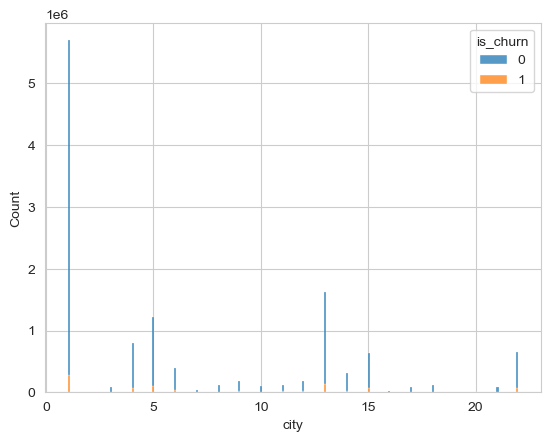

In [ ]:
sns.histplot(members_train, x = 'city', hue = 'is_churn', multiple = 'stack')

### Out of these last features looked at avg_payment_per_day is the only one that seems to significantly contribute

<Axes: xlabel='is_churn', ylabel='days_since_last_use'>

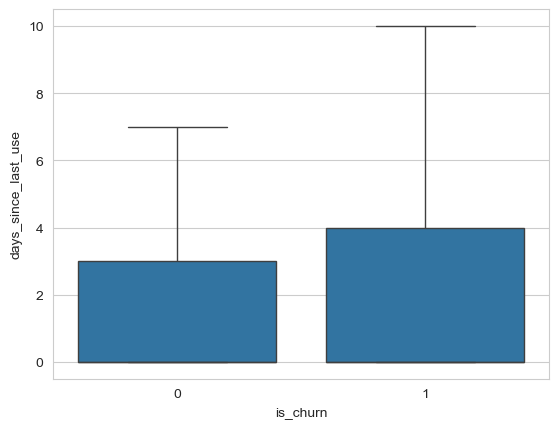

In [ ]:
sns.boxplot(members_train, x = 'is_churn', y = 'days_since_last_use', showfliers = False)

<Axes: xlabel='is_churn', ylabel='num_25_velocity'>

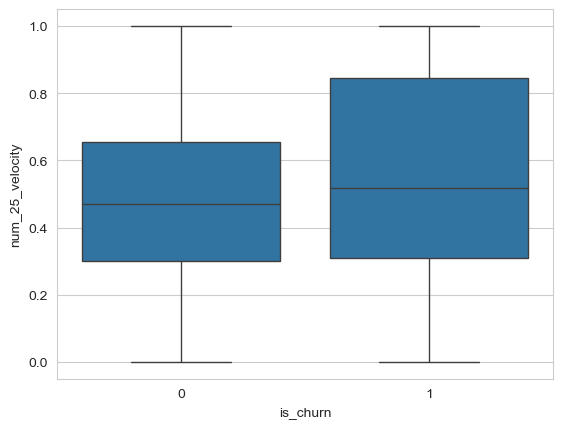

In [ ]:
sns.boxplot(members_train, x = 'is_churn', y = 'num_25_velocity', showfliers = False)

<Axes: xlabel='is_churn', ylabel='num_75_velocity'>

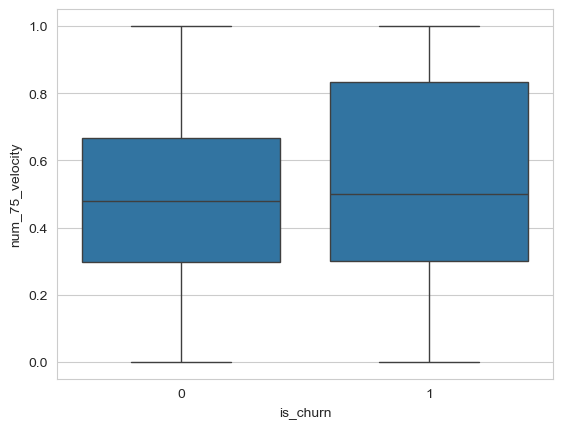

In [ ]:
sns.boxplot(members_train, x = 'is_churn', y = 'num_75_velocity', showfliers = False)

<Axes: xlabel='is_churn', ylabel='num_985_velocity'>

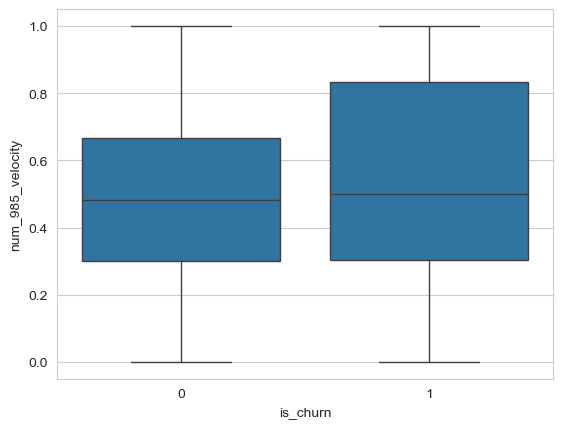

In [ ]:
sns.boxplot(members_train, x = 'is_churn', y = 'num_985_velocity', showfliers = False)

<Axes: xlabel='is_churn', ylabel='num_100_velocity'>

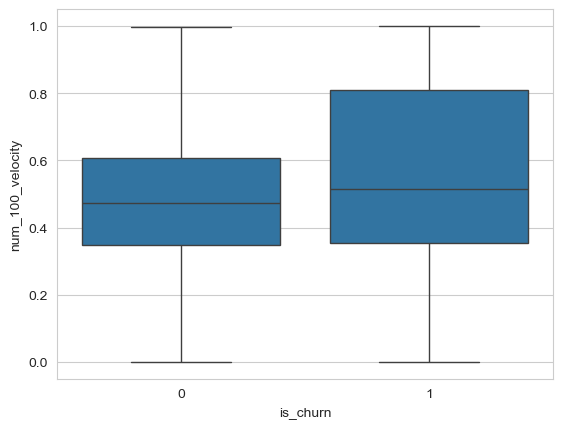

In [ ]:
sns.boxplot(members_train, x = 'is_churn', y = 'num_100_velocity', showfliers = False)

<Axes: xlabel='is_churn', ylabel='num_unq_velocity'>

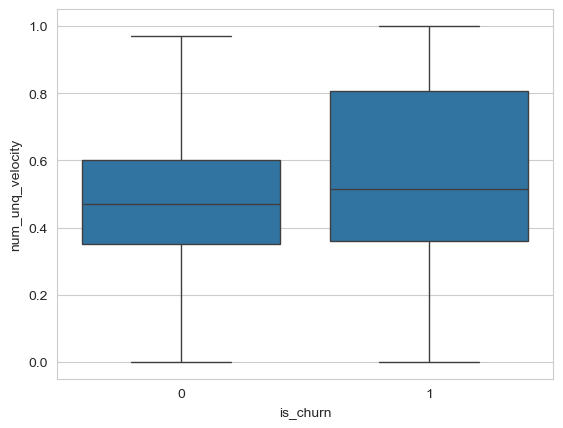

In [ ]:
sns.boxplot(members_train, x = 'is_churn', y = 'num_unq_velocity', showfliers = False)

<Axes: xlabel='is_churn', ylabel='total_secs_velocity'>

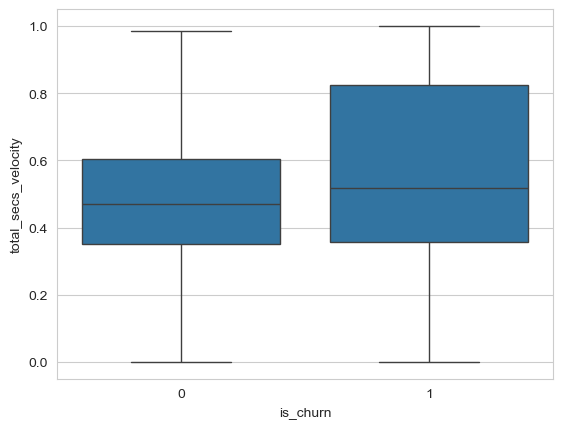

In [ ]:
sns.boxplot(members_train, x = 'is_churn', y = 'total_secs_velocity', showfliers = False)

### Over these last usage features total_secs_velocity, num_unq_velocity, and num_100_velocity show the most promise. Also it just makes sense to include days_since_last_use. So we will include it as a potential feature



# 5. Potential Features


After doing the above analysis, the following features seem the most promising:
* last_is_auto_renew
* ratio_auto_renew
* last_is_cancel
* avg_plan_price
* days_since_first_trans
* avg_payment_per_day
* days_since_last_use
* total_sec_velocity
* num_unq_velocity
* num_100_velocity

# 6. Colinearity Check

Here we check if the above features are colinear by looking at their correlation.

In [ ]:
numerical_columns = ['num_transactions', 'total_paid', 'avg_plan_price', 'total_auto_renew', 'total_cancel', 'days_since_first_trans', 'days_since_last_trans', 'days_to_expire', 'avg_payment_per_day', 'last_payment_plan_days', 'last_plan_list_price', 'last_actual_amount_paid', 'days_since_last_use', 'num_25_velocity', 'num_75_velocity', 'num_985_velocity', 'num_100_velocity', 'num_unq_velocity', 'total_secs_velocity', 'ratio_auto_renew', 'ratio_cancel']

In [ ]:
members_train[numerical_columns].corr()

,num_transactions,total_paid,avg_plan_price,total_auto_renew,total_cancel,days_since_first_trans,days_since_last_trans,days_to_expire,avg_payment_per_day,last_payment_plan_days,last_plan_list_price,last_actual_amount_paid,days_since_last_use,num_25_velocity,num_75_velocity,num_985_velocity,num_100_velocity,num_unq_velocity,total_secs_velocity,ratio_auto_renew,ratio_cancel
num_transactions,1.000000,0.961350,-0.070859,0.924491,0.382653,0.934839,-0.104047,0.016350,0.329091,-0.065297,-0.040196,-0.063549,0.078023,-0.070087,-0.060071,-0.062541,-0.093029,-0.094207,0.000023,0.211929,0.104141
total_paid,0.961350,1.000000,0.104764,0.868791,0.358825,0.950002,0.045947,0.030007,0.409830,0.082811,0.129667,0.120643,0.045022,-0.069986,-0.060213,-0.062679,-0.093378,-0.094328,0.000059,0.119834,0.093630
avg_plan_price,-0.070859,0.104764,1.000000,-0.098468,0.000765,0.094558,0.822945,-0.078797,0.121667,0.888341,0.902619,0.841207,-0.041237,-0.009652,-0.006737,-0.006687,-0.010680,-0.012181,-0.000043,-0.289290,0.011187
total_auto_renew,0.924491,0.868791,-0.098468,1.000000,0.368658,0.830930,-0.116026,0.025173,0.304868,-0.080494,-0.071369,-0.091055,0.102093,-0.073891,-0.063476,-0.066099,-0.096484,-0.097991,-0.000023,0.475834,0.107125
total_cancel,0.382653,0.358825,0.000765,0.368658,1.000000,0.301284,-0.009650,-0.034067,0.217109,-0.007846,-0.012305,-0.024936,-0.032554,-0.015104,-0.012798,-0.013564,-0.020557,-0.020789,0.000113,0.091739,0.722162
days_since_first_trans,0.934839,0.950002,0.094558,0.830930,0.301284,1.000000,0.067481,0.010375,0.217695,0.098482,0.125413,0.114100,0.081853,-0.065529,-0.056398,-0.058285,-0.087598,-0.088774,0.000046,0.095365,0.080451
days_since_last_trans,-0.104047,0.045947,0.822945,-0.116026,-0.009650,0.067481,1.000000,-0.282039,0.025399,0.890930,0.868801,0.903338,-0.020797,-0.025674,-0.021189,-0.020318,-0.026741,-0.029473,-0.000114,-0.247332,0.011140
days_to_expire,0.016350,0.030007,-0.078797,0.025173,-0.034067,0.010375,-0.282039,1.000000,-0.042611,-0.035922,-0.029154,0.020192,-0.003184,0.036652,0.030124,0.027337,0.029096,0.033742,0.000565,0.053718,-0.037958
avg_payment_per_day,0.329091,0.409830,0.121667,0.304868,0.217109,0.217695,0.025399,-0.042611,1.000000,0.024114,0.107379,0.172594,-0.107201,-0.072523,-0.058134,-0.058487,-0.085573,-0.090804,-0.000053,0.022588,0.094537
last_payment_plan_days,-0.065297,0.082811,0.888341,-0.080494,-0.007846,0.098482,0.890930,-0.035922,0.024114,1.000000,0.976870,0.900638,-0.017419,-0.010756,-0.008584,-0.008463,-0.012804,-0.014233,-0.000051,-0.239793,0.008323


### Looking at the correlations, we choose to drop num_100_velocity leaving our features we want to use as:
* last_is_auto_renew
* ratio_auto_renew
* last_is_cancel
* avg_plan_price
* days_since_first_trans
* avg_payment_per_day
* days_since_last_use
* total_sec_velocity
* num_unq_velocity

Note no features from members_v3.csv persisted through our feature selection.